# TFT Training v2 – Cải thiện RMSE

**Các thay đổi so với v1:**
1. ✅ **Log-transform target** (`log1p`) – giảm ảnh hưởng outliers lên RMSE
2. ✅ **Loại duplicate lag features** – chỉ giữ `lags=` trong TimeSeriesDataSet
3. ✅ **Robust GroupNormalizer** – `transformation='robust'` thay vì mean/std mặc định
4. ✅ **Tăng model capacity** – hidden_size=128, hidden_continuous_size=64
5. ✅ **Điều chỉnh training** – gradient_clip_val=0.5, max_epochs=100, lr=3e-4
6. ✅ **Metrics đúng** – inverse log-transform khi tính MAE/RMSE
7. ✅ **Quantile analysis** – phân tích lỗi theo nhóm (low/mid/high)

In [22]:
# ── Cell 1: Import thư viện ──────────────────────────────────────────────────
import sys, subprocess, importlib

for pkg in ["numpy", "torch", "lightning", "pytorch-forecasting", "scikit-learn"]:
    try:
        importlib.import_module(pkg.replace('-', '_'))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import numpy as np
import pandas as pd
import torch
from pathlib import Path

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import r2_score

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.9.1+cu126
CUDA available: True


In [23]:
# ── Cell 2: Load & chuẩn bị dữ liệu ─────────────────────────────────────────
seed_everything(42)
torch.set_float32_matmul_precision("high")

# Load premodel dataset
premodel_path = Path('data\\processed\\tft_premodel_dataset_20.csv')

data = pd.read_csv(premodel_path)
data['date'] = pd.to_datetime(data['date'], errors='coerce')
if 'month' in data.columns:
    data['month'] = data['month'].astype(str)

# Chuẩn hóa target và chặn giá trị quá nhỏ
data['generation_TWh'] = pd.to_numeric(data['generation_TWh'], errors='coerce')
data['generation_TWh'] = data['generation_TWh'].clip(lower=1e-4)

# Clip outliers theo từng group để giảm nhiễu khi dữ liệu hạn chế
def clip_target_by_group(g: pd.DataFrame) -> pd.DataFrame:
    x = g['generation_TWh']
    q01, q99 = x.quantile([0.01, 0.99])
    g['generation_TWh'] = x.clip(lower=q01, upper=q99)
    return g

data = data.groupby(['entity', 'series'], group_keys=False).apply(clip_target_by_group)

# Bật log-transform xuyên suốt pretrain/transfer để giảm lệch phân phối
LOG_TRANSFORM = True

if LOG_TRANSFORM:
    data['generation_TWh'] = np.log1p(data['generation_TWh'])
    print("✅ Đã áp dụng log1p transform lên target")
    print(f"   generation_TWh sau log: min={data['generation_TWh'].min():.3f}, "
          f"max={data['generation_TWh'].max():.3f}, "
          f"mean={data['generation_TWh'].mean():.3f}")

# Pha 2: tái tạo rolling/lag chỉ từ quá khứ để giảm leakage
def rebuild_safe_features(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values('time_idx').copy()
    for w in [3, 6, 12]:
        g[f'target_roll_mean_{w}'] = g['generation_TWh'].shift(1).rolling(w, min_periods=1).mean()
        g[f'target_roll_std_{w}'] = g['generation_TWh'].shift(1).rolling(w, min_periods=1).std().fillna(0)

    if 'precipitation' in g.columns:
        g['precip_roll6'] = g['precipitation'].shift(1).rolling(6, min_periods=1).mean()
        g['precip_roll12'] = g['precipitation'].shift(1).rolling(12, min_periods=1).mean()
    if 'temperature' in g.columns:
        g['temp_roll6'] = g['temperature'].shift(1).rolling(6, min_periods=1).mean()
        g['temp_roll12'] = g['temperature'].shift(1).rolling(12, min_periods=1).mean()

    return g

data = data.groupby(['entity', 'series'], group_keys=False).apply(rebuild_safe_features)

# Không dùng bfill để tránh kéo thông tin tương lai về quá khứ
fill_cols = [c for c in data.columns if 'roll' in c]
for c in fill_cols:
    data[c] = data.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill())
    data[c] = data[c].fillna(0)

# Pha 3: giảm bớt dữ liệu pretrain để phù hợp tỷ lệ với transfer (~500)
TRANSFER_REFERENCE_SIZE = 500
PRETRAIN_TO_TRANSFER_RATIO = 4.0  # có thể chỉnh 3.0 - 6.0
TARGET_PRETRAIN_ROWS = int(TRANSFER_REFERENCE_SIZE * PRETRAIN_TO_TRANSFER_RATIO)
MIN_ROWS_PER_GROUP = 30

before_rows = len(data)
data = data.sort_values(['entity', 'series', 'time_idx']).reset_index(drop=True)

if before_rows > TARGET_PRETRAIN_ROWS:
    grp_cols = ['entity', 'series']
    grp_size = data.groupby(grp_cols).size().rename('n').reset_index()
    n_groups = len(grp_size)

    # Giữ tối thiểu mỗi group đủ lịch sử cho encoder+decoder
    min_budget = n_groups * MIN_ROWS_PER_GROUP
    effective_target = max(TARGET_PRETRAIN_ROWS, min_budget)

    # Dùng trọng số sqrt để giảm thống trị của nhóm quá lớn nhưng vẫn giữ tính đại diện
    grp_size['w'] = np.sqrt(grp_size['n'].astype(float))
    grp_size['quota'] = np.floor(grp_size['w'] / grp_size['w'].sum() * effective_target).astype(int)
    grp_size['quota'] = grp_size['quota'].clip(lower=MIN_ROWS_PER_GROUP)
    grp_size['quota'] = np.minimum(grp_size['quota'], grp_size['n'])

    # Hiệu chỉnh quota để không vượt tổng dữ liệu thực tế
    total_quota = int(grp_size['quota'].sum())
    max_total = int(grp_size['n'].sum())
    target_final = min(effective_target, max_total)

    if total_quota > target_final:
        overflow = total_quota - target_final
        adjustable = grp_size.index[grp_size['quota'] > MIN_ROWS_PER_GROUP].tolist()
        i = 0
        while overflow > 0 and adjustable:
            idx = adjustable[i % len(adjustable)]
            if grp_size.at[idx, 'quota'] > MIN_ROWS_PER_GROUP:
                grp_size.at[idx, 'quota'] -= 1
                overflow -= 1
            i += 1
            adjustable = grp_size.index[grp_size['quota'] > MIN_ROWS_PER_GROUP].tolist()

    quota_map = {
        (r['entity'], r['series']): int(r['quota'])
        for _, r in grp_size.iterrows()
    }

    sampled_parts = []
    for key, g in data.groupby(grp_cols, sort=False):
        q = quota_map.get(key, len(g))
        if len(g) <= q:
            sampled_parts.append(g)
        else:
            # Giữ đoạn cuối chuỗi để bảo toàn ngữ cảnh thời gian gần hiện tại
            sampled_parts.append(g.tail(q))

    data = pd.concat(sampled_parts, ignore_index=True)
    data = data.sort_values(['entity', 'series', 'time_idx']).reset_index(drop=True)

after_rows = len(data)
print(f"\nRows: {after_rows} (trước giảm: {before_rows})")
print(f"Groups: {data[['entity', 'series']].drop_duplicates().shape[0]}")
print(f"Columns: {len(data.columns)}")
print(f"Số lượng Target <= 0: {len(data[data['generation_TWh'] <= 0])}")
print(f"Target pretrain rows (theo tỷ lệ): ~{TARGET_PRETRAIN_ROWS}")

INFO: Seed set to 42


[22:38:19] INFO     Seed set to 42                                   seed.py:57
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ FutureWarning in                                                            │
│ C:\Users\Admin\AppData\Local\Temp\ipykernel_23544\1883941840.py:24          │
│ DataFrameGroupBy.apply operated on the grouping columns. This behavior is   │
│ deprecated, and in a future version of pandas the grouping columns will be  │
│ excluded from the operation. Either pass `include_groups=False` to exclude  │
│ the groupings or explicitly select the grouping columns after groupby to    │
│ silence this warning.                                                       │
└─────────────────────────────────────────────────────────────────────────────┘
✅ Đã áp dụng log1p transform lên target
   generation_TWh sau log: min=0.000, max=6.828, mean=0.976
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ FutureWarning in  

In [24]:
# ── Cell 3: Tạo TimeSeriesDataSet ─────────────────────────────────────────────
# Đồng bộ horizon với transfer stage đầu để giảm domain shift
max_encoder_length = 24
max_prediction_length = 6
batch_size = 32

# Chỉ giữ các chuỗi đủ dài
min_required_length = max_encoder_length + max_prediction_length
series_lengths = data.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]
train_df = data.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

if train_df.empty:
    raise ValueError('Không có chuỗi nào đủ dài để train!')

training_cutoff = train_df['time_idx'].max() - max_prediction_length

known_candidates = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature',
    'precip_roll6', 'precip_roll12', 'temp_roll6', 'temp_roll12'
]
unknown_candidates = [
    'generation_TWh',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12'
]

known_reals = [c for c in known_candidates if c in train_df.columns]
unknown_reals = [c for c in unknown_candidates if c in train_df.columns]

print("known_reals:  ", known_reals)
print("unknown_reals:", unknown_reals)

training = TimeSeriesDataSet(
    train_df[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=12,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=['entity', 'series'],
        center=True,
    ),
    lags={'generation_TWh': [1, 2, 3, 6, 12]},
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    train_df,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f"\nDataset OK – training samples: {len(training)}, validation samples: {len(validation)}")

known_reals:   ['time_idx', 'month_sin', 'month_cos', 'precipitation', 'solar', 'humidity', 'temperature', 'precip_roll6', 'precip_roll12', 'temp_roll6', 'temp_roll12']
unknown_reals: ['generation_TWh', 'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12', 'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12']
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ UserWarning in                                                              │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\py │
│ torch_forecasting\data\timeseries\_timeseries.py:1859                       │
│ Min encoder length and/or min_prediction_idx and/or min prediction length   │
│ and/or lags are too large for 336 series/groups which therefore are not     │
│ present in the dataset index. This means no predictions can be made for     │
│ those series. First 10 removed groups: [{'__group_id__entity': 'Australia', │
│ '__group_id__series': 'B

In [25]:
# ── Cell 4: Tạo & Train mô hình ───────────────────────────────────────────────
import os
os.makedirs("checkpoint", exist_ok=True)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
devices = 1
use_bf16 = accelerator == 'gpu' and hasattr(torch.cuda, 'is_bf16_supported') and torch.cuda.is_bf16_supported()
precision = 'bf16-mixed' if use_bf16 else 32
print(f"🚀 Training accelerator: {accelerator} | devices={devices} | precision={precision}")

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=15,
    verbose=True,
    mode='min'
)
lr_logger = LearningRateMonitor()
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='tft_v2_best-{epoch:02d}-{val_loss:.4f}'
)
logger = CSVLogger('lightning_logs', name='tft_v2_improved')

trainer = Trainer(
    max_epochs=100,
    accelerator=accelerator,
    devices=devices,
    precision=precision,
    gradient_clip_val=0.5,
    callbacks=[lr_logger, early_stop_callback, checkpoint_callback],
    logger=logger,
    enable_model_summary=True,
    log_every_n_steps=10,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=3e-4,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.15,
    hidden_continuous_size=64,
    loss=QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    log_interval=10,
    reduce_on_plateau_patience=5,
    mask_bias=-1e4,
)

print(f"Số tham số model: {tft.size()/1e3:.1f}k")

# Train
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: Using bfloat16 Automatic Mixed Precision (AMP)


🚀 Training accelerator: gpu | devices=1 | precision=bf16-mixed
[22:38:24] INFO     Using bfloat16 Automatic Mixed accelerator_connector.py:486
                    Precision (AMP)                                            


INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


...

[22:38:27] INFO     Metric val_loss improved. New best    early_stopping.py:305
                    score: 0.050                                               


INFO: Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.049


[22:38:28] INFO     Metric val_loss improved by 0.001 >=  early_stopping.py:305
                    min_delta = 0.0001. New best score:                        
                    0.049                                                      


INFO: Monitored metric val_loss did not improve in the last 15 records. Best score: 0.049. Signaling Trainer to stop.


[22:38:40] INFO     Monitored metric val_loss did not     early_stopping.py:305
                    improve in the last 15 records. Best                       
                    score: 0.049. Signaling Trainer to                         
                    stop.                                                      


In [26]:
# ── Cell 5: Đánh giá trên validation set ─────────────────────────────────────
torch.set_grad_enabled(False)

# Dự đoán raw (cho plot)
raw_pred_obj = tft.predict(val_loader, mode='raw', return_x=True)
if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple):
    raw_predictions = raw_pred_obj[0]
    x = raw_pred_obj[1] if len(raw_pred_obj) > 1 else None
else:
    raw_predictions = raw_pred_obj
    x = None

# Dự đoán point (median)
point_pred_obj = tft.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

# Actuals (trong log-space nếu LOG_TRANSFORM=True)
actuals = torch.cat([y[0] for _, y in iter(val_loader)])

print(f"pred shape:   {point_predictions.shape}")
print(f"actual shape: {actuals.shape}")

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 5: METRICS ĐÚNG – INVERSE LOG-TRANSFORM
# Luôn tính metrics trên scale GỐC (TWh) để so sánh với v1
# ══════════════════════════════════════════════════════════════════════
if LOG_TRANSFORM:
    # Chuyển về scale gốc (TWh)
    actuals_orig = torch.expm1(actuals)
    preds_orig   = torch.expm1(point_predictions)
    # Clip âm (không nên xảy ra nhưng phòng ngừa)
    actuals_orig = actuals_orig.clamp(min=0)
    preds_orig   = preds_orig.clamp(min=0)
    print("\n📊 Metrics trên scale LOG (dùng để check training):")
else:
    actuals_orig = actuals
    preds_orig   = point_predictions

# Metrics trong log-space
mae_log  = (actuals - point_predictions).abs().mean().item()
rmse_log = torch.sqrt(((actuals - point_predictions) ** 2).mean()).item()
print(f"   MAE  (log): {mae_log:.4f}")
print(f"   RMSE (log): {rmse_log:.4f}")

# Metrics trên scale gốc (TWh)
mae  = (actuals_orig - preds_orig).abs().mean().item()
rmse = torch.sqrt(((actuals_orig - preds_orig) ** 2).mean()).item()
wape = ((actuals_orig - preds_orig).abs().sum() / (actuals_orig.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals_orig.detach().cpu().numpy().reshape(-1)
y_pred_np = preds_orig.detach().cpu().numpy().reshape(-1)
r2 = r2_score(y_true_np, y_pred_np)

print(f"\n📊 Metrics trên scale GỐC (TWh)  so sánh với v1:")
print(f"   MAE : {mae:.4f}  (v1: 0.5729)")
print(f"   RMSE: {rmse:.4f}  (v1: 1.6225)")
print(f"   WAPE: {wape:.4f}%  (v1: 15.81%)")
print(f"   R²  : {r2:.4f}  (v1: 0.9796)")

INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61
pred shape:   torch.Size([176, 6])
actual shape: torch.Size([176, 6])

📊 Metrics trên scale LOG (dùng để check training):
   MAE  (log): 0.0816
   RMSE (log): 0.1441

📊 Metrics trên scale GỐC (TWh)  so sánh với v1:
   MAE : 2.9703  (v1: 0.5729)
   RMSE: 16.9061  (v1: 1.6225)
   WAPE: 12.7138%  (v1: 15.81%)
   R²  : 0.9744  (v1: 0.9796)


In [27]:
# ── Cell 6: Phân tích lỗi theo quantile (trên scale gốc) ────────────────────
eval_df = pd.DataFrame({
    "y_true": y_true_np,
    "y_pred": y_pred_np,
    "abs_error": np.abs(y_true_np - y_pred_np)
})

q10 = eval_df["y_true"].quantile(0.10)
q90 = eval_df["y_true"].quantile(0.90)

low_df  = eval_df[eval_df["y_true"] <= q10]
mid_df  = eval_df[(eval_df["y_true"] > q10) & (eval_df["y_true"] < q90)]
high_df = eval_df[eval_df["y_true"] >= q90]

def calc_wape(df_sub):
    if len(df_sub) == 0: return 0.0
    return (df_sub['abs_error'].sum() / (df_sub['y_true'].abs().sum() + 1e-8)) * 100

print("=" * 60)
print(f"Low  10% (<= {q10:.2f} TWh) → MAE: {low_df['abs_error'].mean():.4f} | WAPE: {calc_wape(low_df):.2f}% (n={len(low_df)})")
print(f"Mid  80%               → MAE: {mid_df['abs_error'].mean():.4f} | WAPE: {calc_wape(mid_df):.2f}% (n={len(mid_df)})")
print(f"High 10% (>= {q90:.2f} TWh) → MAE: {high_df['abs_error'].mean():.4f} | WAPE: {calc_wape(high_df):.2f}% (n={len(high_df)})")
print("=" * 60)

high_bias = (high_df["y_pred"] - high_df["y_true"]).mean()
print(f"\nHigh 10% mean bias: {high_bias:.4f}")
print("  (âm = dự báo THẤP hơn thực tế, dương = dự báo CAO hơn thực tế)")

Low  10% (<= 0.00 TWh) → MAE: 0.0031 | WAPE: 3091.20% (n=127)
Mid  80%               → MAE: 0.2366 | WAPE: 17.56% (n=823)
High 10% (>= 11.91 TWh) → MAE: 27.7503 | WAPE: 12.48% (n=106)

High 10% mean bias: -21.7705
  (âm = dự báo THẤP hơn thực tế, dương = dự báo CAO hơn thực tế)


Vẽ chuỗi idx=96 (lỗi trung vị = 0.0409 log-TWh)


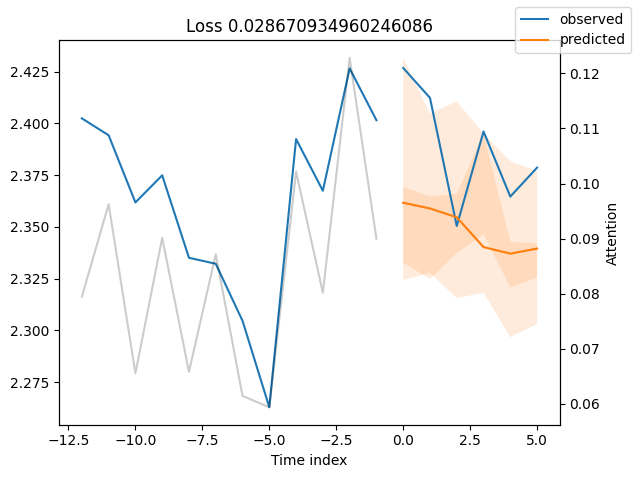

In [28]:
# ── Cell 7: Vẽ prediction plot (chọn chuỗi có lỗi trung vị) ─────────────────
if x is not None:
    err_per_series = (actuals - point_predictions).abs().mean(dim=1)
    idx_plot = int(torch.argsort(err_per_series)[len(err_per_series) // 2].item())
    print(f"Vẽ chuỗi idx={idx_plot} (lỗi trung vị = {err_per_series[idx_plot].item():.4f} log-TWh)")
    _ = tft.plot_prediction(x, raw_predictions, idx=idx_plot, add_loss_to_title=True)
else:
    print("Không có x để vẽ")

In [29]:
# ── Cell 8: Lưu model ────────────────────────────────────────────────────────
import shutil, os

os.makedirs("checkpoint", exist_ok=True)

# Lưu state cuối cùng
trainer.save_checkpoint("checkpoint/tft_v2_latest.ckpt")
print("✅ Đã lưu model cuối cùng → checkpoint/tft_v2_latest.ckpt")

# Copy best checkpoint
if trainer.checkpoint_callback and trainer.checkpoint_callback.best_model_path:
    best_path = trainer.checkpoint_callback.best_model_path
    shutil.copy(best_path, "checkpoint/tft_v2_best.ckpt")
    print(f"✅ Best model (val_loss tốt nhất) → checkpoint/tft_v2_best.ckpt")
    print(f"   (source: {best_path})")

print("\n📌 Load lại mô hình:")
print("   from pytorch_forecasting import TemporalFusionTransformer")
print("   model = TemporalFusionTransformer.load_from_checkpoint('checkpoint/tft_v2_best.ckpt')")

INFO: `weights_only` was not set, defaulting to `False`.


[22:38:42] INFO     `weights_only` was not set,     checkpoint_connector.py:455
                    defaulting to `False`.                                     
✅ Đã lưu model cuối cùng → checkpoint/tft_v2_latest.ckpt
✅ Best model (val_loss tốt nhất) → checkpoint/tft_v2_best.ckpt
   (source: lightning_logs\tft_v2_improved\version_4\checkpoints\tft_v2_best-epoch=01-val_loss=0.0492.ckpt)

📌 Load lại mô hình:
   from pytorch_forecasting import TemporalFusionTransformer
   model = TemporalFusionTransformer.load_from_checkpoint('checkpoint/tft_v2_best.ckpt')


In [30]:
# ── Cell 9: Chuẩn bị cho Transfer Learning sang Vietnam ──────────────────────
# Lưu training dataset config để dùng khi fine-tune
import pickle, os

os.makedirs("checkpoint", exist_ok=True)

# Lưu training dataset (cần để từ_dataset() khi load model)
with open("checkpoint/training_dataset_v2.pkl", "wb") as f:
    pickle.dump(training, f)
print("✅ Đã lưu training dataset config → checkpoint/training_dataset_v2.pkl")

# Lưu thông tin LOG_TRANSFORM để biết khi load
config = {
    'LOG_TRANSFORM': LOG_TRANSFORM,
    'max_encoder_length': max_encoder_length,
    'max_prediction_length': max_prediction_length,
    'group_ids': ['entity', 'series'],
    'target': 'generation_TWh',
    'known_reals': known_reals,
    'unknown_reals': unknown_reals,
}
import json
with open("checkpoint/model_config_v2.json", "w") as f:
    json.dump(config, f, indent=2)
print("✅ Đã lưu model config → checkpoint/model_config_v2.json")
print()
print("📌 Thông tin quan trọng cho transfer learning:")
print(f"   LOG_TRANSFORM = {LOG_TRANSFORM}")
print(f"   → Khi chuẩn bị Vietnam data, cần áp dụng log1p transform")
print(f"   → Khi đánh giá, cần inverse transform bằng expm1")

✅ Đã lưu training dataset config → checkpoint/training_dataset_v2.pkl
✅ Đã lưu model config → checkpoint/model_config_v2.json

📌 Thông tin quan trọng cho transfer learning:
   LOG_TRANSFORM = True
   → Khi chuẩn bị Vietnam data, cần áp dụng log1p transform
   → Khi đánh giá, cần inverse transform bằng expm1
